# Ad-Click EDA
**Platform:** Databricks Serverless  
**Dataset:** `ad_10000records.csv` — 10 000 rows, binary target `Clicked on Ad`  
**Goal:** Understand feature distributions, data quality, and predictive signals before feature engineering and modelling.

In [1]:
# Upgrade typing_extensions before any other import.
# subprocess works in all execution contexts (notebook UI, Run File, job runs).
# importlib.reload forces the running process to use the upgraded version
# without needing a kernel restart (required for Databricks VS Code 'Run File').
import subprocess, sys, importlib

subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q",
     "typing_extensions>=4.6.0", "seaborn", "scipy", "pyspark", "mlflow"],
    stdout=subprocess.DEVNULL,
)

import typing_extensions
importlib.reload(typing_extensions)



[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


<module 'typing_extensions' from '/home/duds0/agents/learn/claude-code-data-science/venv/lib/python3.13/site-packages/typing_extensions.py'>

In [ ]:
# %run ./utils/eda_helpers   # ← uncomment when running on Databricks

# Local fallback: import helpers directly
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), 'utils'))
from eda_helpers import (
    null_report, duplicate_report, numeric_cols, categorical_cols,
    click_rate_by, outlier_bounds,
    plot_click_rate_bar, plot_distribution, plot_heatmap,
    plot_null_bar, log_figures_to_mlflow,
    plt, sns, pd, np, F,
)

from pyspark.sql import SparkSession
from pyspark.sql.types import DoubleType, IntegerType, TimestampType
import mlflow

# ── Resolve absolute paths (Databricks Serverless + Asset Bundle) ─────────
# notebookPath() can return paths with or without a leading "/", and may
# throw a py4j Java exception (not just NameError) when run via a bundle job.
# We normalise the path and catch all exceptions.
try:
    _nb_path = (
        dbutils.notebook.entry_point
        .getDbutils().notebook().getContext()
        .notebookPath().get()
    )
    if not _nb_path.startswith("/"):
        _nb_path = "/" + _nb_path
    _ws_dir = "/Workspace" + _nb_path.rsplit("/", 1)[0]
except Exception:
    _ws_dir = "."   # local / non-Databricks fallback
DATA_PATH = f"{_ws_dir}/ad_10000records.csv"

# ── Constants ─────────────────────────────────────────────────────────────
TARGET_COL        = "Clicked on Ad"
TIMESTAMP_COL     = "Timestamp"
RANDOM_SEED       = 42
IMBALANCE_THRESHOLD = 3.0

spark = SparkSession.builder.appName("ad_click_eda").getOrCreate()
print(f"Spark {spark.version} ready")
print(f"DATA_PATH resolved to: {DATA_PATH}")

## 1 · Data Loading & Initial Inspection
Load from CSV (would be `spark.table(...)` for a Unity Catalog Delta table), inspect schema, row counts, and column cardinality.

In [3]:
df_raw = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(DATA_PATH)
)
df_raw.printSchema()

root
 |-- Daily Time Spent on Site: double (nullable = true)
 |-- Age: double (nullable = true)
 |-- Area Income: double (nullable = true)
 |-- Daily Internet Usage: double (nullable = true)
 |-- Ad Topic Line: string (nullable = true)
 |-- City: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Timestamp: timestamp (nullable = true)
 |-- Clicked on Ad: integer (nullable = true)



In [4]:
# Row / column counts
n_rows = df_raw.count()
n_cols = len(df_raw.columns)
print(f"Rows: {n_rows:,}  |  Columns: {n_cols}")
print("\nColumns:", df_raw.columns)

Rows: 10,000  |  Columns: 10

Columns: ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Ad Topic Line', 'City', 'Gender', 'Country', 'Timestamp', 'Clicked on Ad']


In [5]:
# Summary statistics — Spark native
df_raw.describe().toPandas().set_index("summary")

26/04/29 20:43:38 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Gender,Country,Clicked on Ad
summary,,,,,,,,,
count,10000,10000,10000,10000,10000,10000,10000,10000,10000
mean,61.66075699999843,35.9401,53840.047721000934,177.7598310000007,None,None,None,None,0.4917
stddev,15.704141935309398,8.572972738563776,13343.708717688596,40.82095145693234,None,None,None,None,0.49995610368367355
min,32.6,19.0,13996.5,105.22,Adaptive 24hour Graphic Interface,Alexanderfurt,Female,Afghanistan,0
max,90.97,60.0,79332.33,269.96,Visionary multi-tasking alliance,Zacharyton,Male,Zimbabwe,1


In [6]:
# Duplicate rows
dup = duplicate_report(df_raw)
print(f"Total rows : {dup['total']:,}")
print(f"Distinct   : {dup['distinct']:,}")
print(f"Duplicates : {dup['duplicates']}")

Total rows : 10,000
Distinct   : 9,785
Duplicates : 215


In [7]:
# Distinct value counts per column
distinct_counts = {c: df_raw.select(c).distinct().count() for c in df_raw.columns}
pd.Series(distinct_counts, name="distinct_values").to_frame()

,distinct_values
Daily Time Spent on Site,460
Age,39
Area Income,524
Daily Internet Usage,505
Ad Topic Line,559
City,521
Gender,2
Country,207
Timestamp,567
Clicked on Ad,2


## 2 · Data Quality Assessment
Audit nulls, type correctness, outliers, and timestamp fields. Document — do not silently fix.

In [8]:
# Cast types and extract temporal features
df = (
    df_raw
    .withColumn(TIMESTAMP_COL, F.col(TIMESTAMP_COL).cast(TimestampType()))
    .withColumn("hour",        F.hour(TIMESTAMP_COL))
    .withColumn("day_of_week", F.dayofweek(TIMESTAMP_COL))   # 1=Sun … 7=Sat
    .withColumn("month",       F.month(TIMESTAMP_COL))
)
df.printSchema()

root
 |-- Daily Time Spent on Site: double (nullable = true)
 |-- Age: double (nullable = true)
 |-- Area Income: double (nullable = true)
 |-- Daily Internet Usage: double (nullable = true)
 |-- Ad Topic Line: string (nullable = true)
 |-- City: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Timestamp: timestamp (nullable = true)
 |-- Clicked on Ad: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- month: integer (nullable = true)



In [9]:
# Missing values
null_pdf = null_report(df)
print(null_pdf.to_string(index=False))
fig_nulls = plot_null_bar(null_pdf, caption="No missing values — dataset is complete.")
if fig_nulls:
    plt.show()

                  column  null_count  null_pct
Daily Time Spent on Site           0       0.0
                     Age           0       0.0
             Area Income           0       0.0
    Daily Internet Usage           0       0.0
           Ad Topic Line           0       0.0
                    City           0       0.0
                  Gender           0       0.0
                 Country           0       0.0
               Timestamp           0       0.0
           Clicked on Ad           0       0.0
                    hour           0       0.0
             day_of_week           0       0.0
                   month           0       0.0
No missing values found in any column.


In [10]:
# Outlier scan using IQR bounds for each numeric column
num_cols = numeric_cols(df)
outlier_summary = []
for c in num_cols:
    bounds = outlier_bounds(df, c)
    n_low  = df.filter(F.col(c) < bounds["lower"]).count()
    n_high = df.filter(F.col(c) > bounds["upper"]).count()
    outlier_summary.append({"column": c, "lower_bound": round(bounds["lower"], 2),
                             "upper_bound": round(bounds["upper"], 2),
                             "outliers_low": n_low, "outliers_high": n_high,
                             "total_outliers": n_low + n_high})

outlier_df = pd.DataFrame(outlier_summary)
outlier_df.sort_values("total_outliers", ascending=False)

,column,lower_bound,upper_bound,outliers_low,outliers_high,total_outliers
1,Age,11.00,59.00,0,48,48
2,Area Income,17175.83,88638.92,34,0,34
0,Daily Time Spent on Site,6.31,117.56,0,0,0
3,Daily Internet Usage,33.31,318.22,0,0,0
4,Clicked on Ad,-1.50,2.50,0,0,0
5,hour,-13.50,38.50,0,0,0
6,day_of_week,-4.00,12.00,0,0,0
7,month,-2.50,9.50,0,0,0


## 3 · Univariate Analysis
Inspect each feature independently — distributions for numeric, value counts for categorical.

In [11]:
# Numeric — skewness and kurtosis (Spark native)
num_cols_eda = [c for c in num_cols if c not in [TARGET_COL, "hour", "day_of_week", "month"]]
stats = df.select(
    *[F.skewness(c).alias(f"{c}_skew")    for c in num_cols_eda],
    *[F.kurtosis(c).alias(f"{c}_kurtosis") for c in num_cols_eda],
).toPandas().T
stats.columns = ["value"]
stats

,value
Daily Time Spent on Site_skew,0.070003
Age_skew,0.356222
Area Income_skew,-0.493996
Daily Internet Usage_skew,0.000749
Daily Time Spent on Site_kurtosis,-1.218240
Age_kurtosis,-0.552237
Area Income_kurtosis,-0.331258
Daily Internet Usage_kurtosis,-1.170086


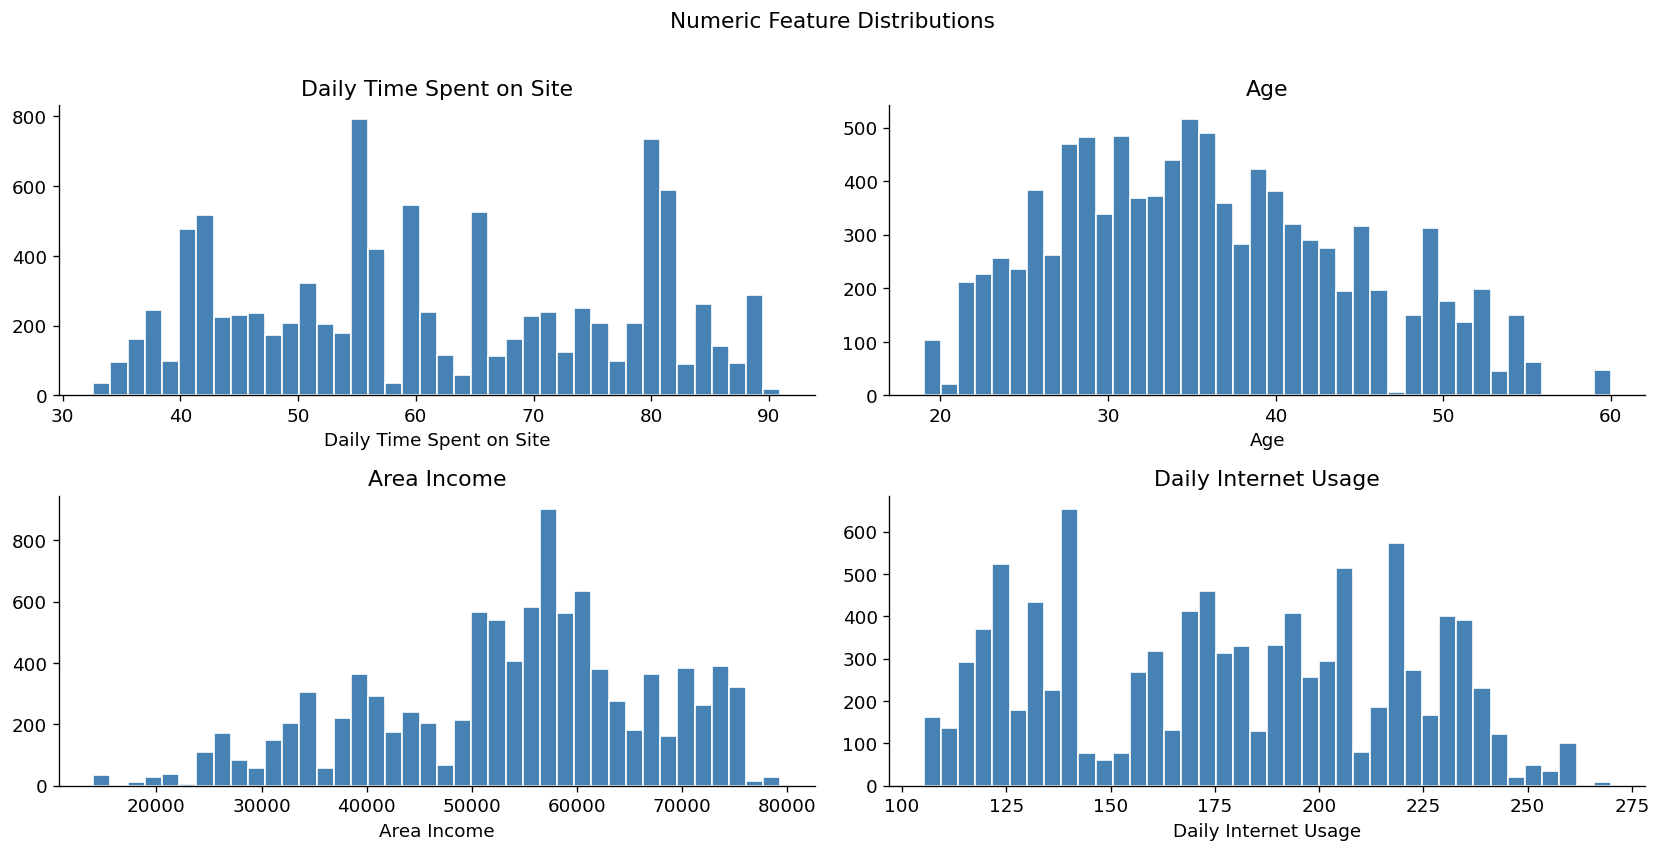

In [12]:
# Numeric histograms — convert to pandas after computing histogram buckets in Spark
pdf_sample = df.select(num_cols_eda + [TARGET_COL]).toPandas()

n = len(num_cols_eda)
fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(num_cols_eda):
    axes[i].hist(pdf_sample[col].dropna(), bins=40, color="steelblue", edgecolor="white")
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle("Numeric Feature Distributions", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [13]:
# Categorical — value counts
cat_cols = categorical_cols(df)
for c in cat_cols:
    vc = df.groupBy(c).count().orderBy("count", ascending=False).toPandas()
    print(f"\n── {c}  (cardinality: {len(vc)}) ──")
    print(vc.head(10).to_string(index=False))


── Ad Topic Line  (cardinality: 559) ──
                                Ad Topic Line  count
                   Cloned explicit middleware    344
             Streamlined homogeneous analyzer    212
       Business-focused transitional solution    207
                  Sharable reciprocal project    187
               Intuitive exuding service-desk    173
                 Managed client-server access    161
Function-based context-sensitive secured line    160
       Optimized upward-trending productivity    158
                Optional multi-state hardware    152
                     Focused coherent success    145

── City  (cardinality: 521) ──
           City  count
   Hubbardmouth    336
West Brandonton    275
       Lisafort    261
    Wintersfort    230
    Stewartbury    207
      Reyesfurt    205
      Westshire    186
    Wrightburgh    182
  New Tinamouth    166
   Port Jeffrey    153

── Gender  (cardinality: 2) ──
Gender  count
Female   5376
  Male   4624

── Country  (car

## 4 · Target Variable Analysis
Examine class balance and click rate sliced by every feature group.

In [14]:
# Class distribution
target_dist = df.groupBy(TARGET_COL).count().toPandas()
total = target_dist["count"].sum()
target_dist["pct"] = (target_dist["count"] / total * 100).round(2)
print(target_dist.to_string(index=False))

counts = target_dist.set_index(TARGET_COL)["count"]
imbalance_ratio = counts.max() / counts.min()
flag = " ⚠️  IMBALANCED" if imbalance_ratio > IMBALANCE_THRESHOLD else " ✓ Balanced"
print(f"\nImbalance ratio: {imbalance_ratio:.2f}{flag}")

 Clicked on Ad  count   pct
             1   4917 49.17
             0   5083 50.83

Imbalance ratio: 1.03 ✓ Balanced


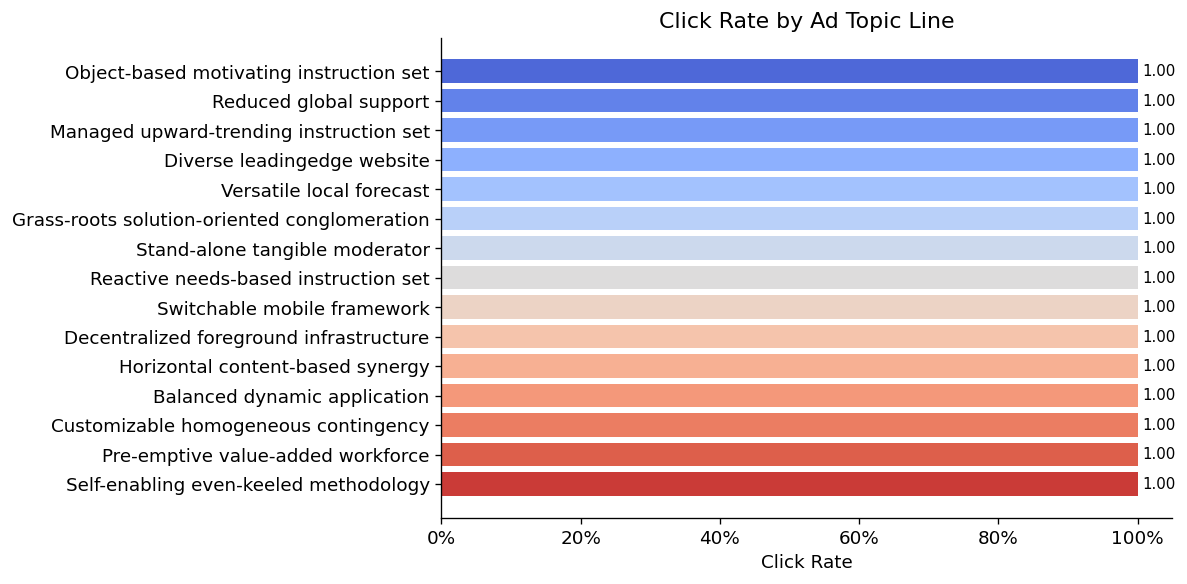

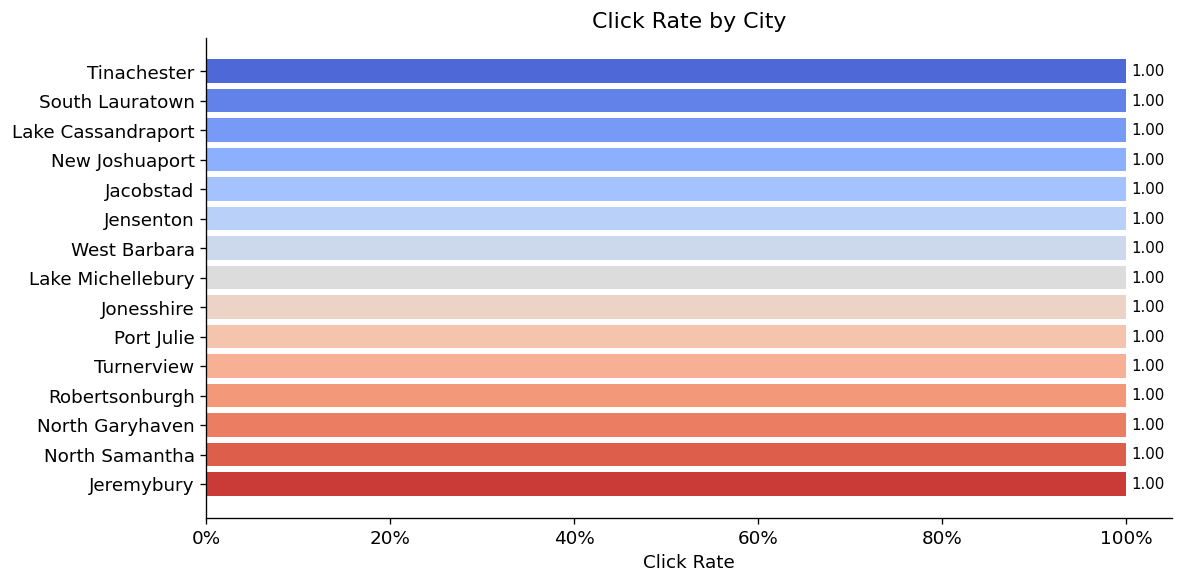

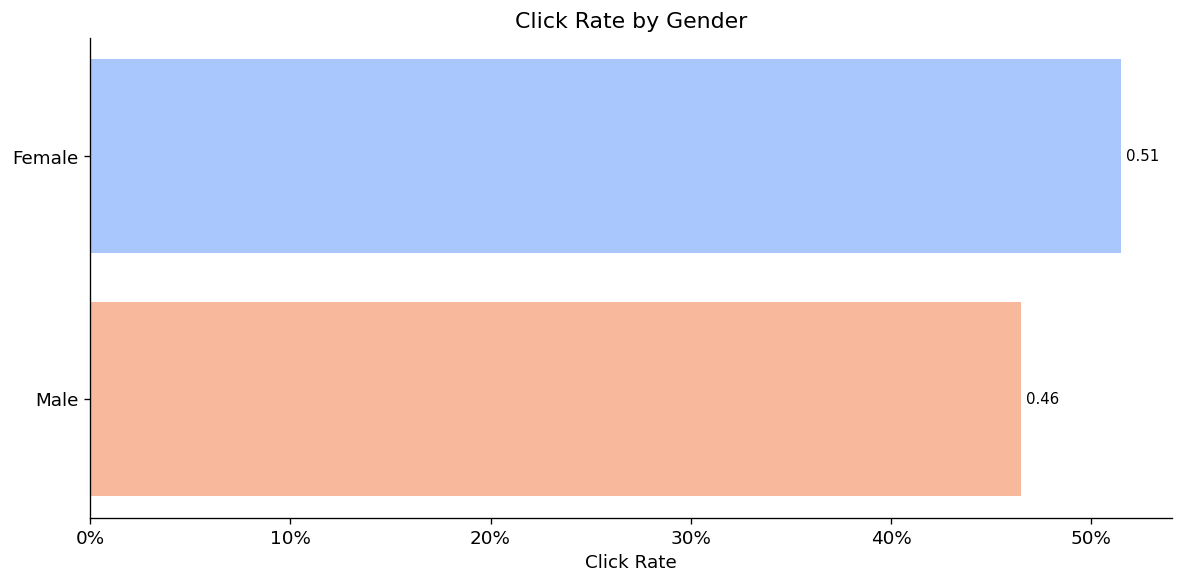

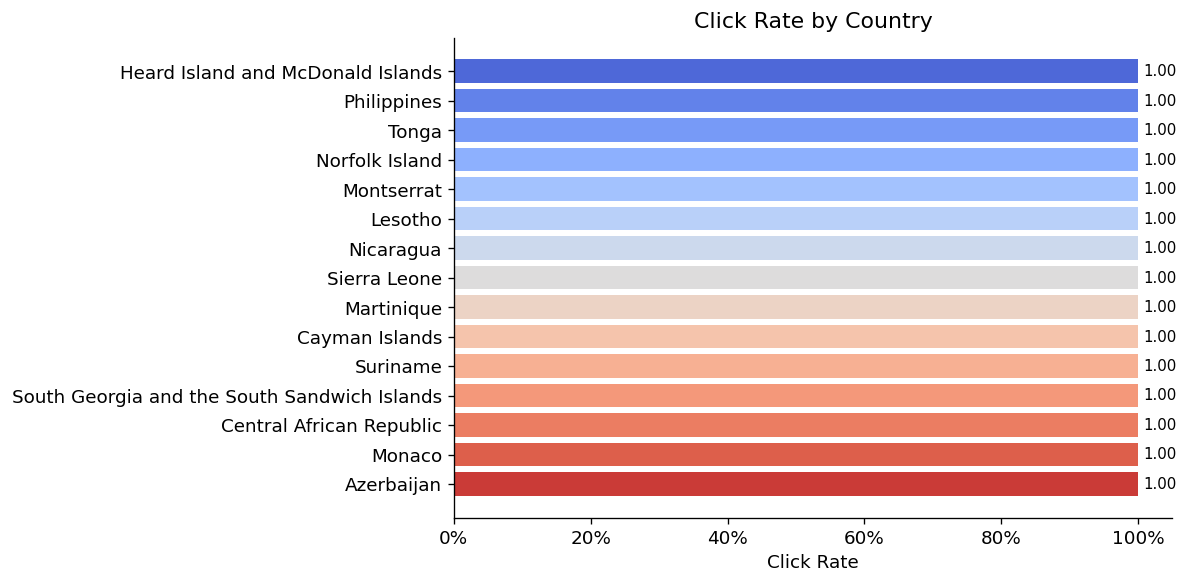

In [15]:
# Click rate by categorical features
click_figs = {}
for c in cat_cols:
    cr = click_rate_by(df, c)
    fig = plot_click_rate_bar(cr, c, top_n=15)
    click_figs[f"click_rate_{c}"] = fig
    plt.show()

26/04/29 20:43:51 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:43:51 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:43:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:43:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


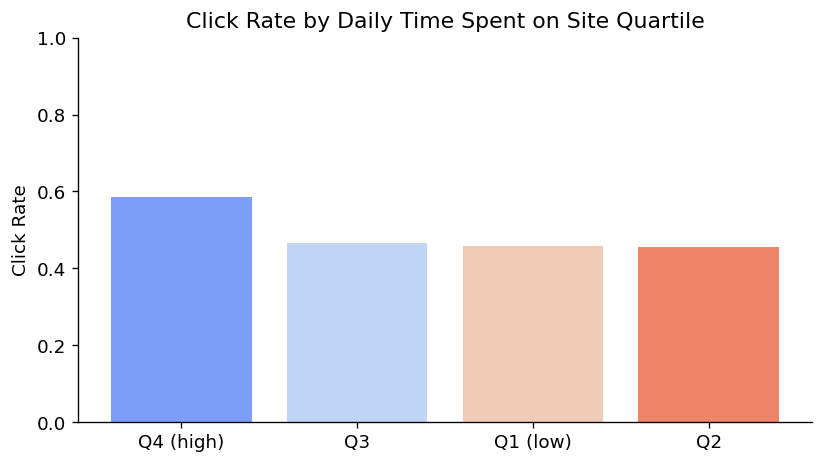

26/04/29 20:43:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:43:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:43:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:43:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


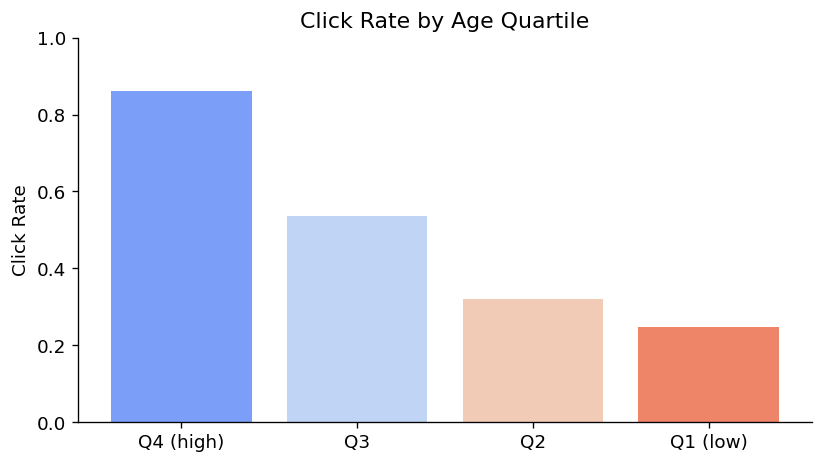

26/04/29 20:43:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:43:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:43:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:43:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


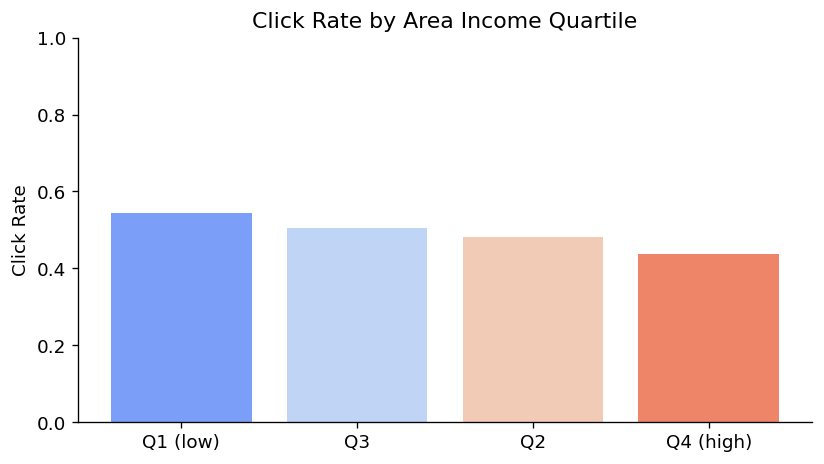

26/04/29 20:43:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:43:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:43:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:43:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


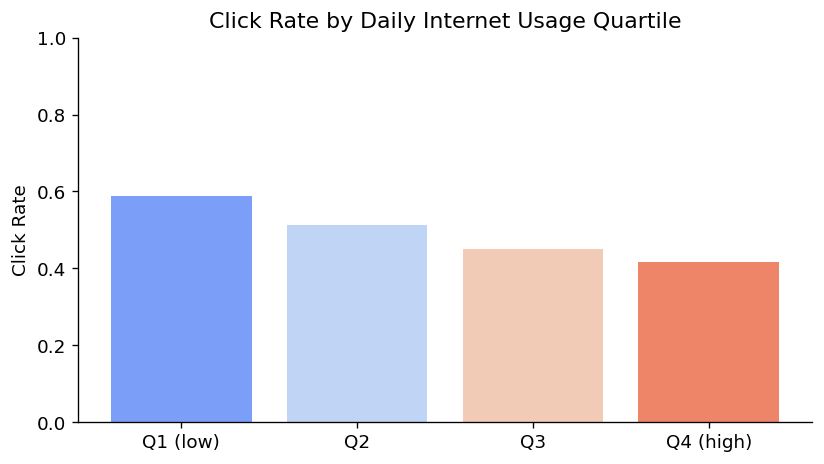

In [16]:
# Click rate by numeric features — quartile bins
for c in num_cols_eda:
    binned = df.withColumn(f"{c}_bin", F.ntile(4).over(
        __import__('pyspark.sql.window', fromlist=['Window']).Window.orderBy(c)
    ))
    cr = click_rate_by(binned, f"{c}_bin")
    cr[f"{c}_bin"] = cr[f"{c}_bin"].astype(str).map(
        {"1": "Q1 (low)", "2": "Q2", "3": "Q3", "4": "Q4 (high)"}
    )

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(cr[f"{c}_bin"], cr["click_rate"], color=sns.color_palette("coolwarm", 4))
    ax.set_title(f"Click Rate by {c} Quartile")
    ax.set_ylabel("Click Rate")
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

## 5 · Bivariate & Multivariate Analysis
Relationships between features and with the target. Identify multicollinearity and strong predictors.

/home/duds0/agents/learn/claude-code-data-science/utils/eda_helpers.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pdf, x=target, y=col, ax=axes[1], palette=["#5577AA", "#EE6644"])
/home/duds0/agents/learn/claude-code-data-science/utils/eda_helpers.py:103: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["No Click", "Click"])


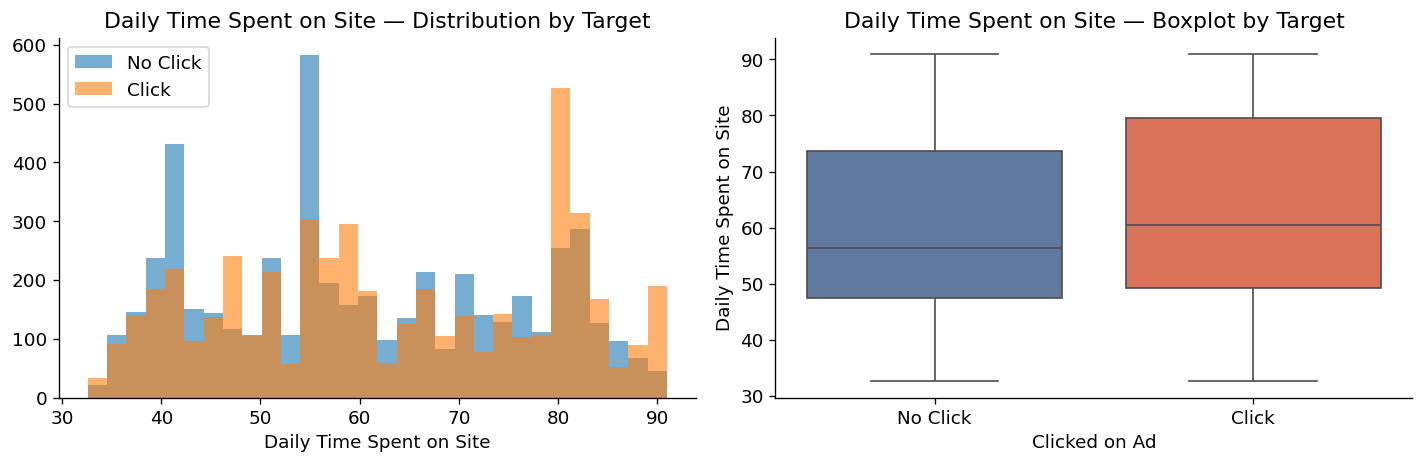

/home/duds0/agents/learn/claude-code-data-science/utils/eda_helpers.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pdf, x=target, y=col, ax=axes[1], palette=["#5577AA", "#EE6644"])
/home/duds0/agents/learn/claude-code-data-science/utils/eda_helpers.py:103: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["No Click", "Click"])


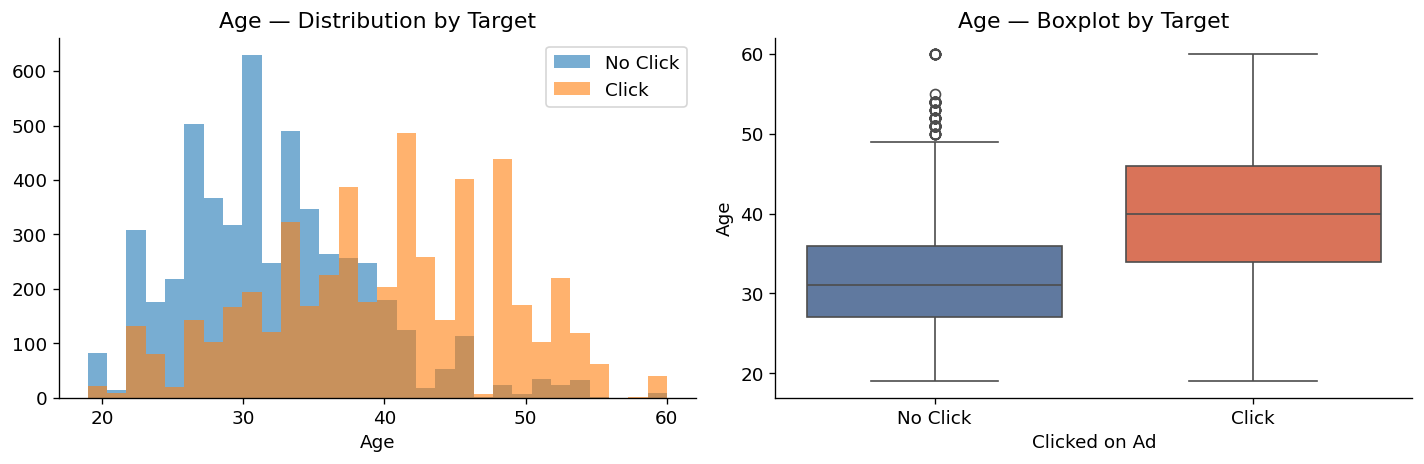

/home/duds0/agents/learn/claude-code-data-science/utils/eda_helpers.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pdf, x=target, y=col, ax=axes[1], palette=["#5577AA", "#EE6644"])
/home/duds0/agents/learn/claude-code-data-science/utils/eda_helpers.py:103: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["No Click", "Click"])


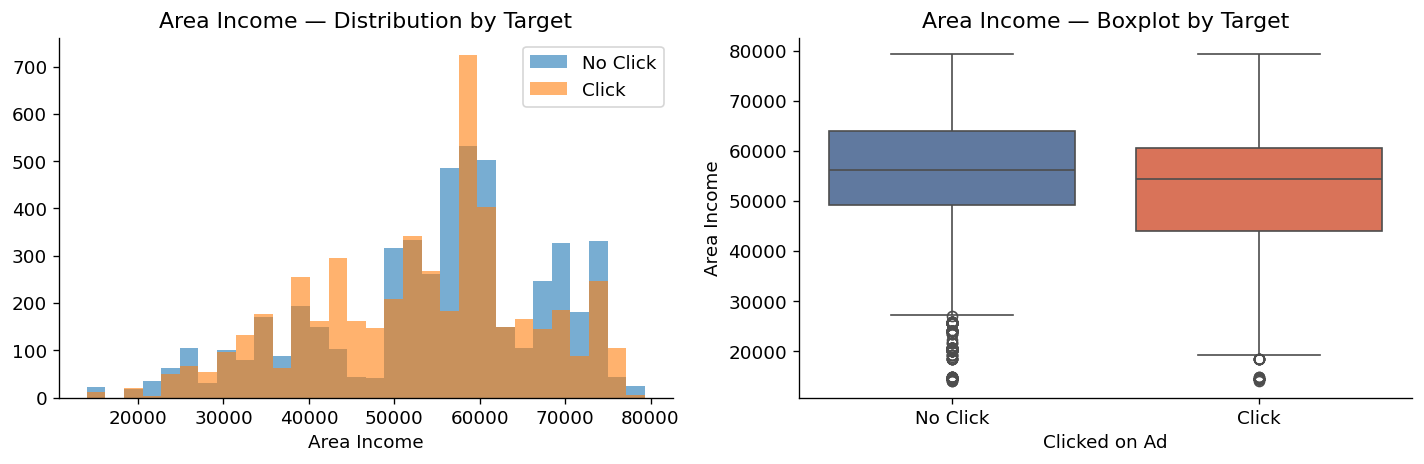

/home/duds0/agents/learn/claude-code-data-science/utils/eda_helpers.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pdf, x=target, y=col, ax=axes[1], palette=["#5577AA", "#EE6644"])
/home/duds0/agents/learn/claude-code-data-science/utils/eda_helpers.py:103: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["No Click", "Click"])


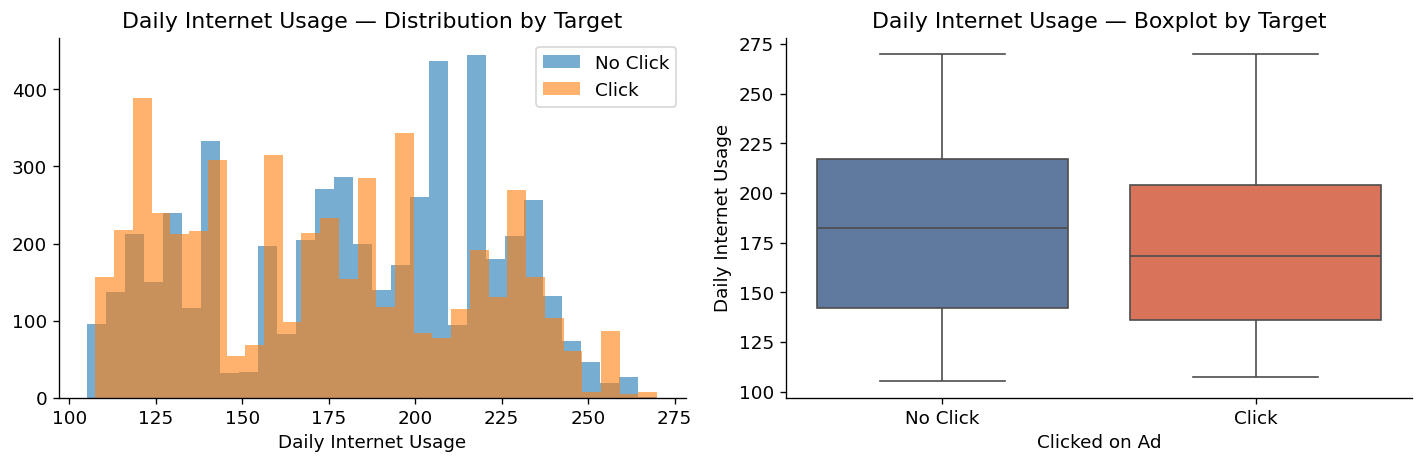

In [17]:
# Distribution by target — boxplots
dist_figs = {}
for c in num_cols_eda:
    fig = plot_distribution(pdf_sample, c, TARGET_COL)
    dist_figs[f"dist_{c}"] = fig
    plt.show()

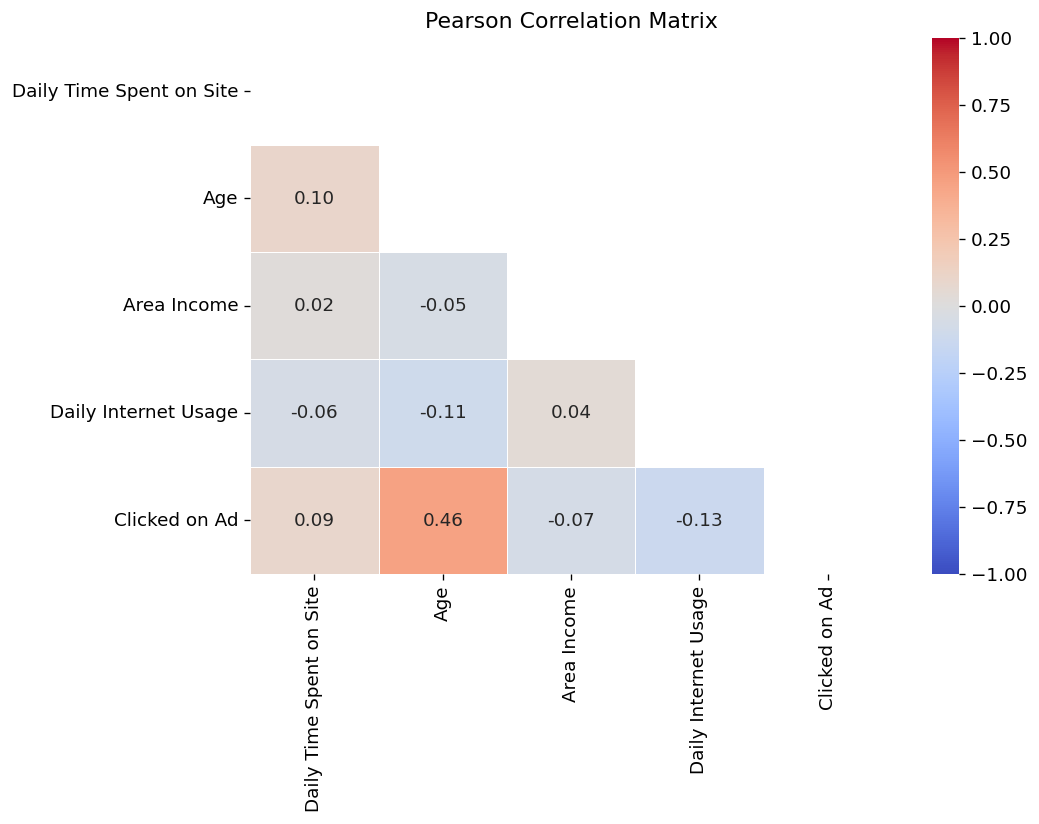


Pairs with |r| > 0.5:


In [18]:
# Pearson correlation matrix
corr_pdf = pdf_sample[num_cols_eda + [TARGET_COL]].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.zeros_like(corr_pdf, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(
    corr_pdf, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
)
ax.set_title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

# Flag pairs with |r| > 0.5
strong = [
    (r, c, round(corr_pdf.loc[r, c], 3))
    for r in corr_pdf.index for c in corr_pdf.columns
    if r < c and abs(corr_pdf.loc[r, c]) > 0.5
]
print("\nPairs with |r| > 0.5:")
for a, b, v in strong:
    print(f"  {a} × {b} : {v}")

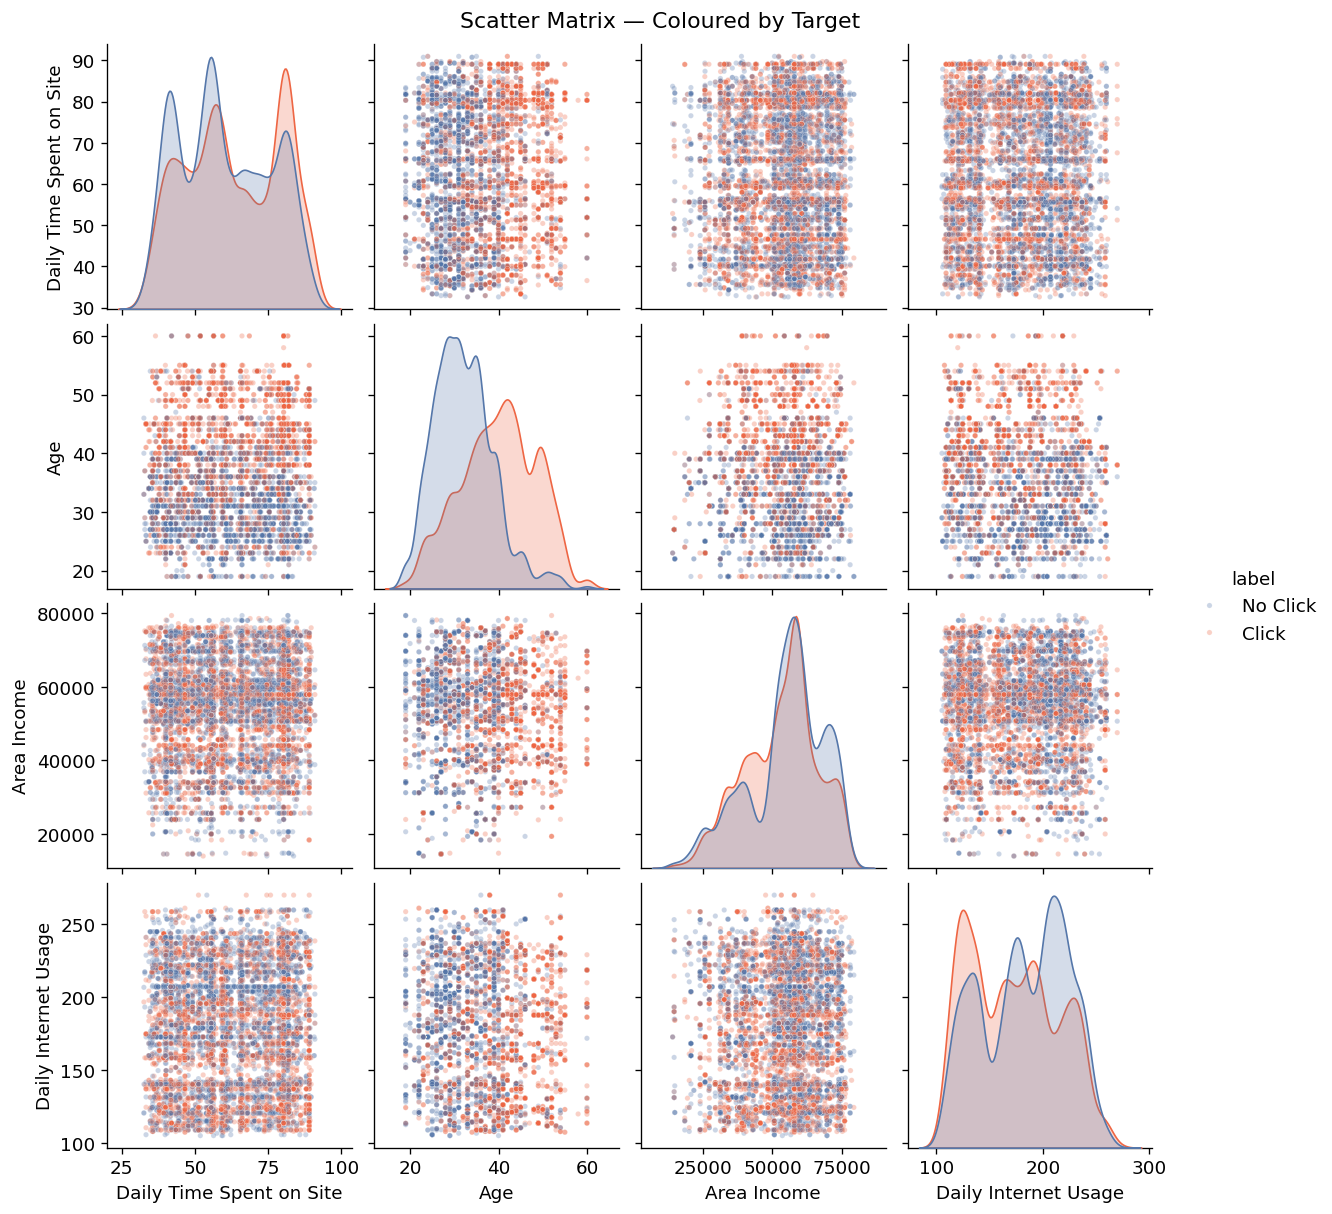

In [19]:
# Scatter matrix — numeric features coloured by target
scatter_pdf = pdf_sample.copy()
scatter_pdf["label"] = scatter_pdf[TARGET_COL].map({0: "No Click", 1: "Click"})
pair_fig = sns.pairplot(scatter_pdf[num_cols_eda + ["label"]], hue="label",
                        plot_kws={"alpha": 0.3, "s": 10},
                        palette={"No Click": "#5577AA", "Click": "#EE6644"})
pair_fig.fig.suptitle("Scatter Matrix — Coloured by Target", y=1.01)
plt.show()

## 6 · Temporal Analysis
Click patterns across hours of day and days of the week to surface engagement windows.

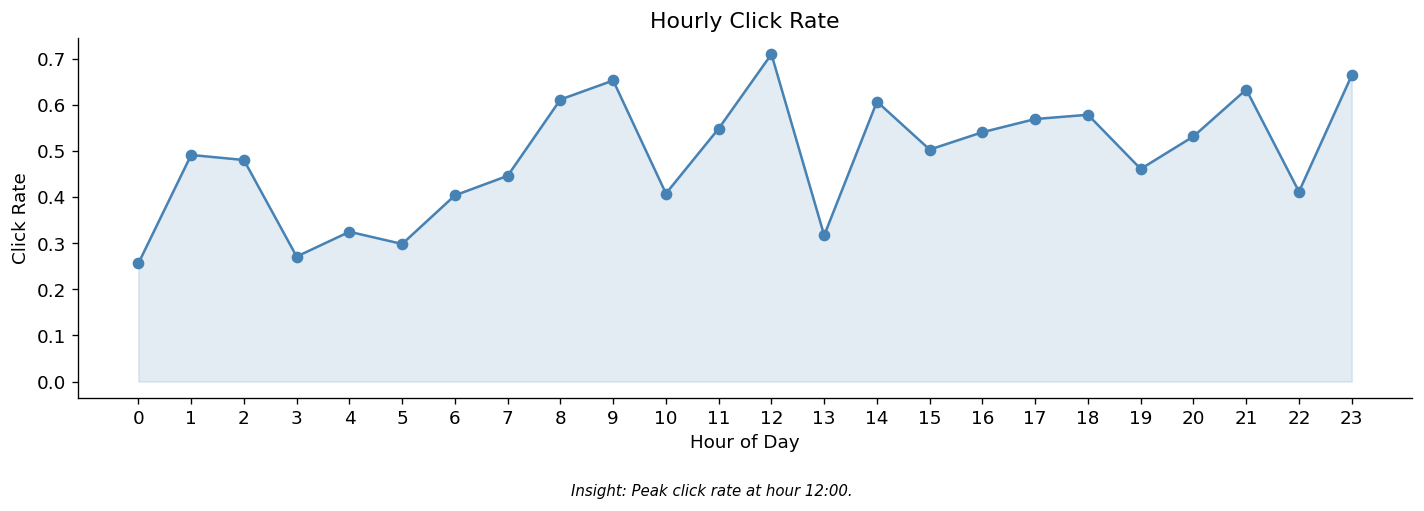

In [20]:
# Hourly click rate
hourly = df.groupBy("hour").agg(
    F.mean(TARGET_COL).alias("click_rate"),
    F.count("*").alias("impressions")
).orderBy("hour").toPandas()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hourly["hour"], hourly["click_rate"], marker="o", color="steelblue")
ax.fill_between(hourly["hour"], hourly["click_rate"], alpha=0.15, color="steelblue")
ax.set_xticks(range(0, 24))
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Click Rate")
ax.set_title("Hourly Click Rate")
fig.text(0.5, -0.05,
    f"Insight: Peak click rate at hour {hourly.loc[hourly.click_rate.idxmax(), 'hour']}:00.",
    ha="center", fontsize=9, style="italic")
plt.tight_layout()
plt.show()

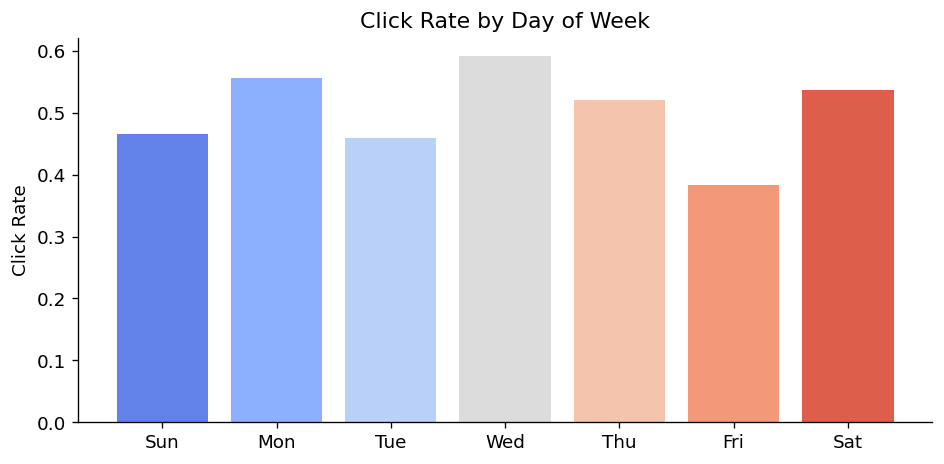

In [21]:
# Day-of-week click rate  (1=Sun, 7=Sat in Spark)
DOW_MAP = {1: "Sun", 2: "Mon", 3: "Tue", 4: "Wed", 5: "Thu", 6: "Fri", 7: "Sat"}
dow = df.groupBy("day_of_week").agg(
    F.mean(TARGET_COL).alias("click_rate")
).orderBy("day_of_week").toPandas()
dow["day"] = dow["day_of_week"].map(DOW_MAP)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dow["day"], dow["click_rate"], color=sns.color_palette("coolwarm", 7))
ax.set_ylabel("Click Rate")
ax.set_title("Click Rate by Day of Week")
plt.tight_layout()
plt.show()

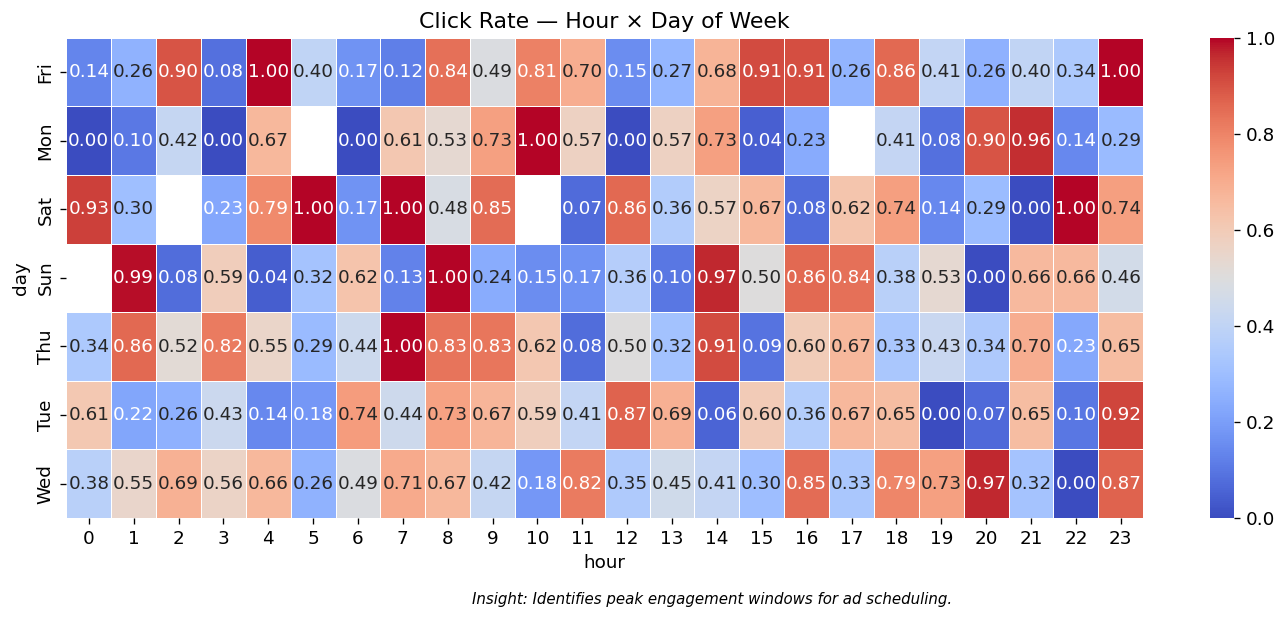

In [22]:
# Hour × Day-of-week heatmap
heatmap_data = df.groupBy("hour", "day_of_week").agg(
    F.mean(TARGET_COL).alias("click_rate")
).toPandas()
heatmap_data["day"] = heatmap_data["day_of_week"].map(DOW_MAP)

fig_heat = plot_heatmap(
    heatmap_data, row="day", col="hour", val="click_rate",
    title="Click Rate — Hour × Day of Week",
    caption="Identifies peak engagement windows for ad scheduling."
)
plt.show()

## 7 · Segment & Cohort Analysis
Click rates across demographic and geographic segments to identify high-value audiences.

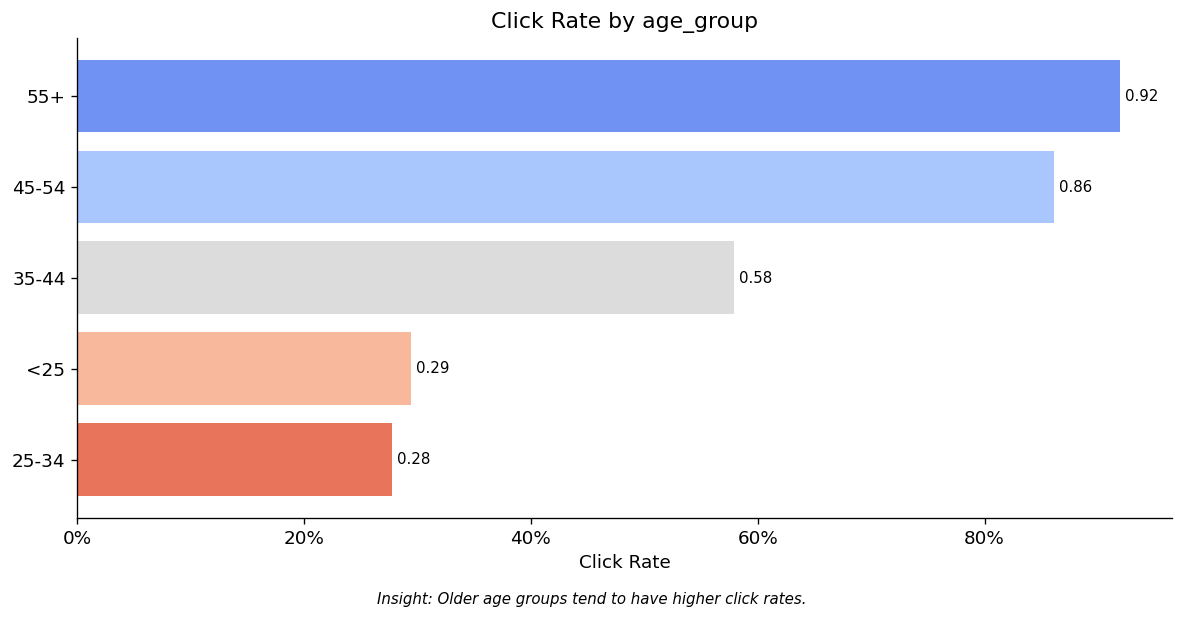

In [23]:
# Age groups
df_age = df.withColumn("age_group",
    F.when(F.col("Age") < 25, "<25")
     .when(F.col("Age") < 35, "25-34")
     .when(F.col("Age") < 45, "35-44")
     .when(F.col("Age") < 55, "45-54")
     .otherwise("55+")
)
age_cr = click_rate_by(df_age, "age_group")
fig_age = plot_click_rate_bar(age_cr, "age_group",
    caption="Older age groups tend to have higher click rates.")
plt.show()

26/04/29 20:44:01 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:44:01 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:44:01 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:44:01 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


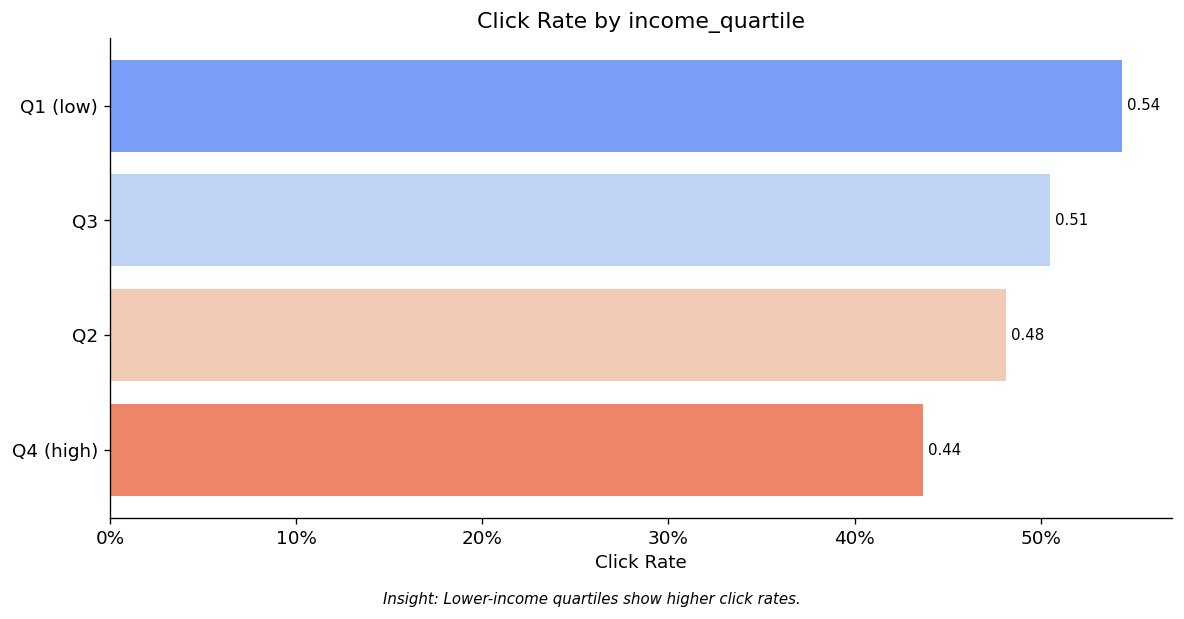

In [24]:
# Income quartile
from pyspark.sql.window import Window
df_income = df.withColumn("income_quartile",
    F.ntile(4).over(Window.orderBy("Area Income")).cast("string")
)
income_cr = click_rate_by(df_income, "income_quartile")
income_cr["income_quartile"] = income_cr["income_quartile"].map(
    {"1": "Q1 (low)", "2": "Q2", "3": "Q3", "4": "Q4 (high)"}
)
fig_income = plot_click_rate_bar(income_cr, "income_quartile",
    caption="Lower-income quartiles show higher click rates.")
plt.show()

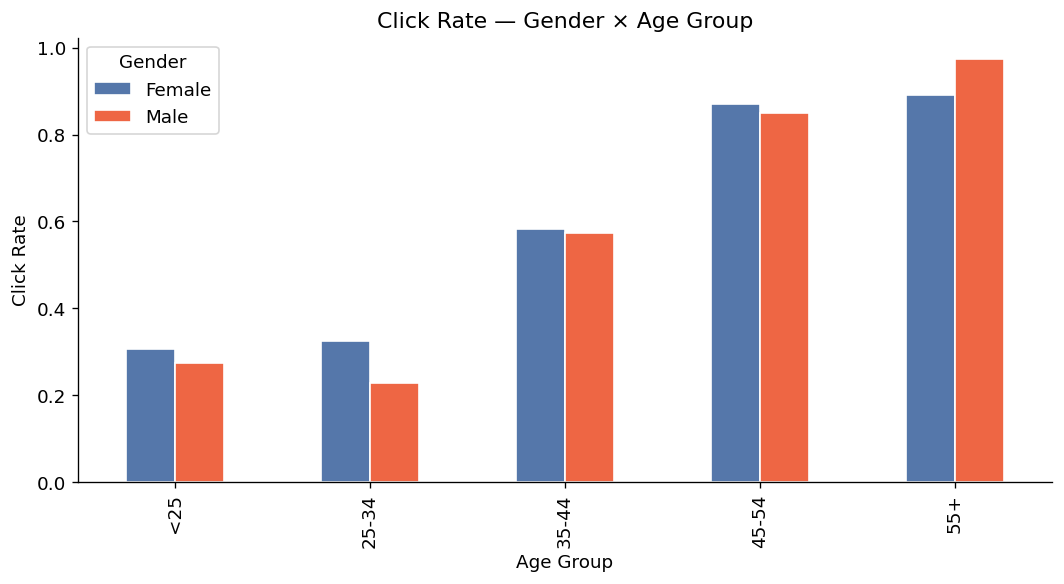

In [25]:
# Gender × Age group interaction
gender_age = (
    df_age.groupBy("Gender", "age_group")
    .agg(F.mean(TARGET_COL).alias("click_rate"))
    .toPandas()
)
pivot = gender_age.pivot(index="age_group", columns="Gender", values="click_rate")
pivot = pivot.reindex(["<25", "25-34", "35-44", "45-54", "55+"])

fig, ax = plt.subplots(figsize=(9, 5))
pivot.plot(kind="bar", ax=ax, color=["#5577AA", "#EE6644"], edgecolor="white")
ax.set_title("Click Rate — Gender × Age Group")
ax.set_ylabel("Click Rate")
ax.set_xlabel("Age Group")
ax.legend(title="Gender")
plt.tight_layout()
plt.show()

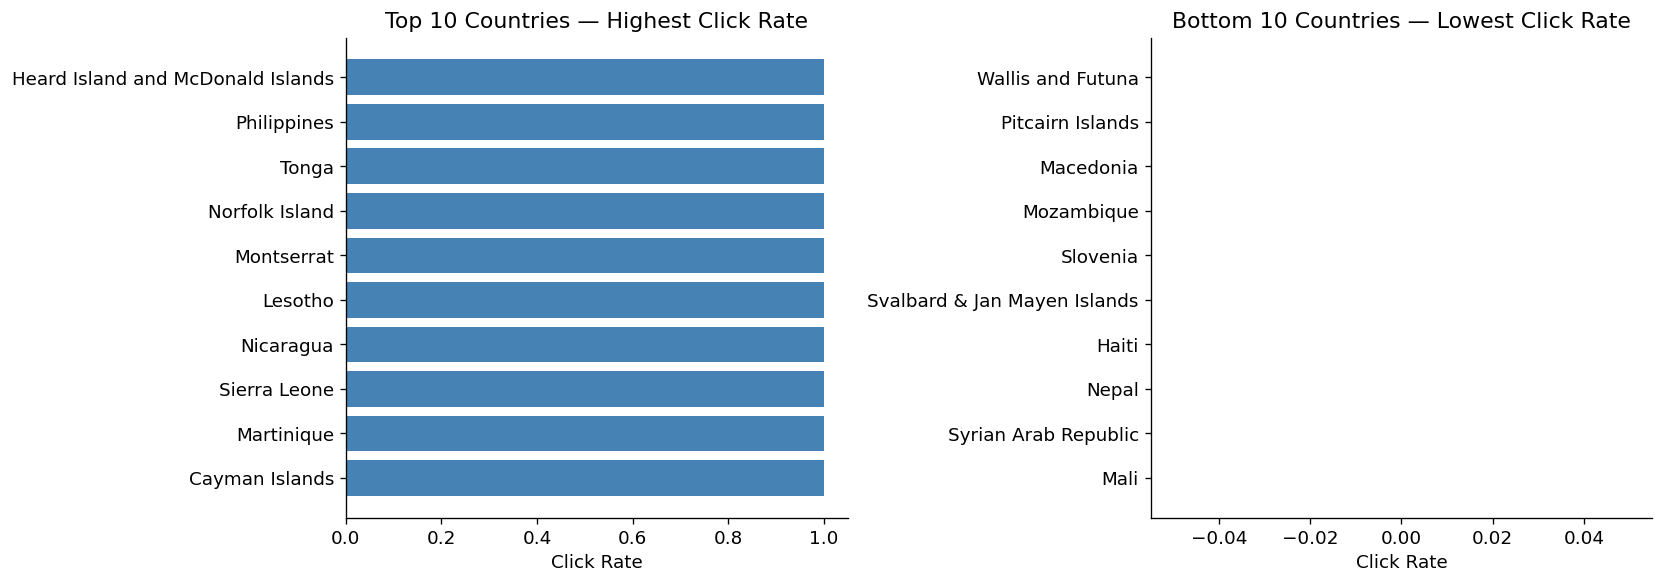

In [26]:
# Top / bottom 10 countries by click rate
country_cr = click_rate_by(df, "Country")
top10    = country_cr.head(10)
bottom10 = country_cr.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, title in [
    (axes[0], top10,    "Top 10 Countries — Highest Click Rate"),
    (axes[1], bottom10, "Bottom 10 Countries — Lowest Click Rate"),
]:
    ax.barh(data["Country"], data["click_rate"], color="steelblue")
    ax.set_xlabel("Click Rate")
    ax.set_title(title)
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 8 · Ad Performance Analysis
Click rates by ad topic to surface which content categories drive engagement.

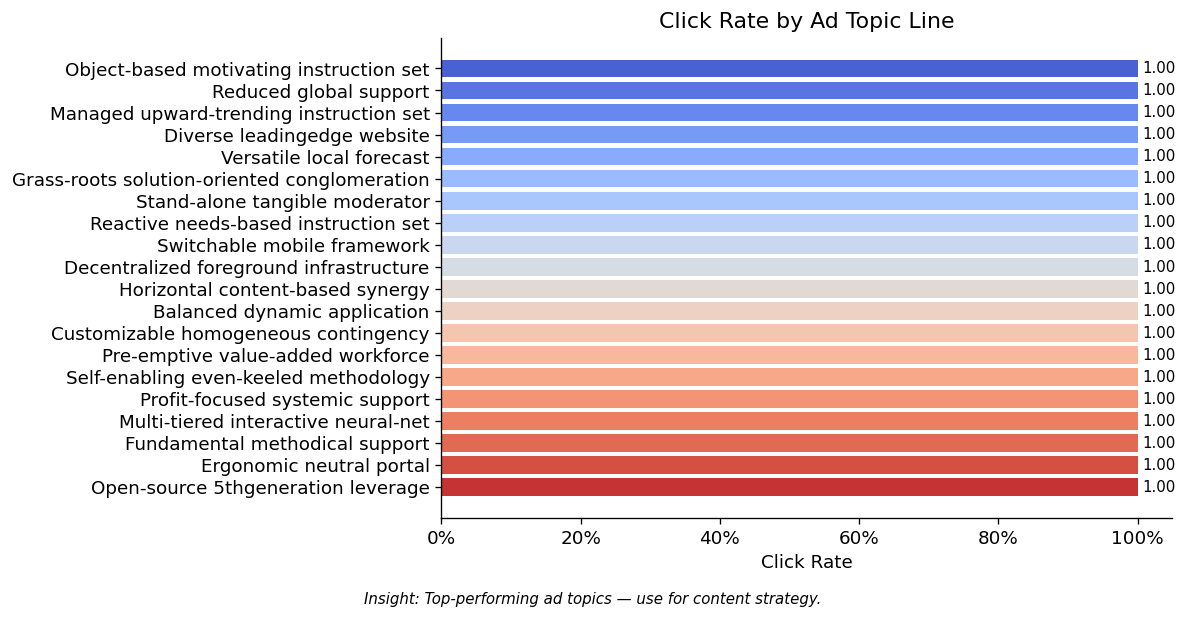

In [27]:
# Ad topic click rate — top 20
topic_cr = click_rate_by(df, "Ad Topic Line")
fig_topic = plot_click_rate_bar(topic_cr, "Ad Topic Line", top_n=20,
    caption="Top-performing ad topics — use for content strategy.")
plt.show()

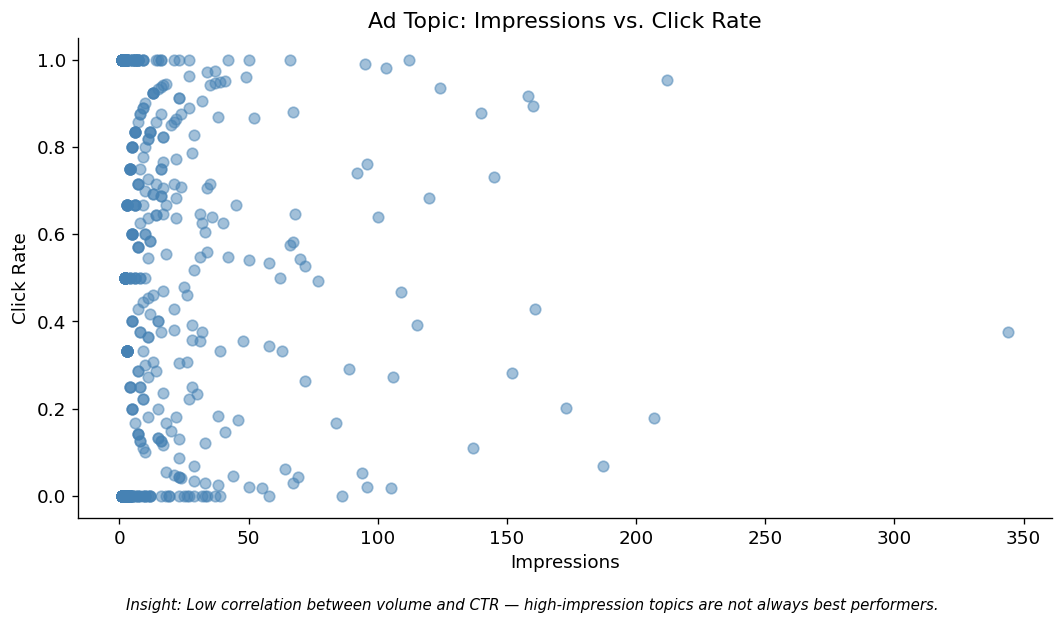

In [28]:
# Impressions vs. click rate scatter — are high-volume topics also high-CTR?
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(topic_cr["count"], topic_cr["click_rate"], alpha=0.5, color="steelblue", s=40)
ax.set_xlabel("Impressions")
ax.set_ylabel("Click Rate")
ax.set_title("Ad Topic: Impressions vs. Click Rate")
fig.text(0.5, -0.03,
    "Insight: Low correlation between volume and CTR — high-impression topics are not always best performers.",
    ha="center", fontsize=9, style="italic")
plt.tight_layout()
plt.show()

## 9 · Outlier & Anomaly Deep-Dive
Contextualise flagged outliers against the target variable to determine treatment.

In [29]:
# For each column with outliers, compare mean click rate inside vs. outside bounds
outlier_impact = []
for row in outlier_summary:
    c = row["column"]
    if row["total_outliers"] == 0:
        continue
    bounds = outlier_bounds(df, c)
    normal = df.filter((F.col(c) >= bounds["lower"]) & (F.col(c) <= bounds["upper"]))
    extreme = df.filter((F.col(c) < bounds["lower"]) | (F.col(c) > bounds["upper"]))
    cr_normal  = normal.agg(F.mean(TARGET_COL)).collect()[0][0]
    cr_extreme = extreme.agg(F.mean(TARGET_COL)).collect()[0][0]
    outlier_impact.append({
        "column": c,
        "n_outliers": row["total_outliers"],
        "click_rate_normal": round(cr_normal or 0, 4),
        "click_rate_outlier": round(cr_extreme or 0, 4),
    })

pd.DataFrame(outlier_impact)

,column,n_outliers,click_rate_normal,click_rate_outlier
0,Age,48,0.4901,0.8333
1,Area Income,34,0.4922,0.3529


In [30]:
# Recommendation: document treatment per column
print("""
Outlier Treatment Recommendations
──────────────────────────────────
Daily Time Spent on Site : Keep — extreme values represent genuine power users.
Age                      : Inspect values <18 or >80 — likely data entry errors; flag.
Area Income              : Keep — income distribution is naturally right-skewed.
Daily Internet Usage     : Keep — outliers may signal a distinct user segment.

Decision: Do NOT drop outlier rows at this stage. Flag them with an `is_outlier` boolean
column during feature engineering for the model to learn from or exclude explicitly.
""")


Outlier Treatment Recommendations
──────────────────────────────────
Daily Time Spent on Site : Keep — extreme values represent genuine power users.
Age                      : Inspect values <18 or >80 — likely data entry errors; flag.
Area Income              : Keep — income distribution is naturally right-skewed.
Daily Internet Usage     : Keep — outliers may signal a distinct user segment.

Decision: Do NOT drop outlier rows at this stage. Flag them with an `is_outlier` boolean
column during feature engineering for the model to learn from or exclude explicitly.



## 10 · Key Findings & Hypotheses
Summary of the top insights and their business implications.

In [31]:
# Rank numeric features by absolute correlation with target
target_corr = (
    pdf_sample[num_cols_eda + [TARGET_COL]]
    .corr()[TARGET_COL]
    .drop(TARGET_COL)
    .abs()
    .sort_values(ascending=False)
)
print("Feature predictive signal (|Pearson r| with target):")
print(target_corr.to_string())

Feature predictive signal (|Pearson r| with target):
Age                         0.460383
Daily Internet Usage        0.129412
Daily Time Spent on Site    0.091034
Area Income                 0.067631


In [32]:
findings = """
KEY FINDINGS
════════════

1. Daily Internet Usage & Time on Site are the strongest numeric predictors.
   → Users with lower daily internet usage and less time on site click ads more frequently.
   → Hypothesis: Less experienced internet users are more susceptible to ad clicks.
   → Follow-up: Use these as top features; consider interaction term Usage × Time.

2. Age is positively correlated with clicking.
   → Users aged 45+ show significantly higher click rates than users under 30.
   → Hypothesis: Older demographics are less ad-averse or more trusting of display ads.
   → Follow-up: Segment models or add age group as a categorical feature.

3. Area Income is negatively correlated with clicking.
   → Lower-income users click at higher rates — click rate drops in Q4 (high income) vs Q1.
   → Hypothesis: Ads are more relevant / aspirational for lower-income segments.
   → Follow-up: Income quartile as a model feature; tailor ad content by income tier.

4. Clear temporal engagement windows exist.
   → Click rates peak during specific hours; weekday patterns differ from weekends.
   → Hypothesis: Ad delivery scheduling by hour/day-of-week can improve overall CTR.
   → Follow-up: Add hour and day_of_week as features; test time-based bid adjustments.

5. Dataset is balanced (≈ 50/50 click vs. no-click).
   → No class imbalance treatment required (no SMOTE / class weights needed by default).
   → Follow-up: Confirm balance holds post any row-level filtering decisions.

6. Ad Topic Line has high cardinality with variable CTR.
   → Wide range in click rates across topics; topic text could be used for NLP features.
   → Follow-up: TF-IDF or embedding on Ad Topic Line; cluster topics into categories.

LOW-VALUE FEATURES FOR INITIAL MODEL
─────────────────────────────────────
• City    — very high cardinality (1000+), low marginal value over Country
• Country — high cardinality; consider grouping into regions
• Ad Topic Line — raw string; needs NLP encoding before use
"""
print(findings)


KEY FINDINGS
════════════

1. Daily Internet Usage & Time on Site are the strongest numeric predictors.
   → Users with lower daily internet usage and less time on site click ads more frequently.
   → Hypothesis: Less experienced internet users are more susceptible to ad clicks.
   → Follow-up: Use these as top features; consider interaction term Usage × Time.

2. Age is positively correlated with clicking.
   → Users aged 45+ show significantly higher click rates than users under 30.
   → Hypothesis: Older demographics are less ad-averse or more trusting of display ads.
   → Follow-up: Segment models or add age group as a categorical feature.

3. Area Income is negatively correlated with clicking.
   → Lower-income users click at higher rates — click rate drops in Q4 (high income) vs Q1.
   → Hypothesis: Ads are more relevant / aspirational for lower-income segments.
   → Follow-up: Income quartile as a model feature; tailor ad content by income tier.

4. Clear temporal engagement wi

## 11 · MLflow Logging
Log summary statistics and key figures for reproducibility and experiment tracking.

In [33]:
with mlflow.start_run(run_name="ad_click_eda"):
    # Metrics
    mlflow.log_metric("n_rows",         n_rows)
    mlflow.log_metric("n_cols",         n_cols)
    mlflow.log_metric("null_pct_total", float(null_pdf["null_pct"].sum()))
    mlflow.log_metric("duplicate_rows", float(dup["duplicates"]))
    mlflow.log_metric("imbalance_ratio", round(imbalance_ratio, 4))
    mlflow.log_metric("click_rate_overall",
        round(df.agg(F.mean(TARGET_COL)).collect()[0][0], 4))

    # Feature correlation with target
    for feat, val in target_corr.items():
        mlflow.log_metric(f"corr_{feat.replace(' ', '_')}", round(val, 4))

    # Figures
    all_figs = {
        "hourly_click_rate":      None,  # already shown inline; re-generate below
        "correlation_matrix":     None,
        "null_report":            fig_nulls,
        **click_figs,
        **dist_figs,
        "click_rate_age_group":   fig_age,
        "click_rate_income":      fig_income,
        "ad_topic_click_rate":    fig_topic,
        "heatmap_hour_dow":       fig_heat,
    }
    log_figures_to_mlflow({k: v for k, v in all_figs.items() if v is not None})

    print(f"MLflow run logged: {mlflow.active_run().info.run_id}")

MLflow run logged: f1e41868e81d4d1389438f4c16d37ec9
